### Bike Buyers Classification
Compare KNN and XGBoost on the Bike Buyers dataset.

##### 1. Imports: import classifier algorithms, import pandas for tabular data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,classification_report,ConfusionMatrixDisplay
from xgboost import XGBClassifier


##### 2. Load Dataset

In [2]:
df = pd.read_csv(r'C:\Users\PC1\Downloads\Applied_Data_Science\data\bike_buyers.csv')
display(df.head())
df.info()

,ID,Marital Status,Gender,Income,Children,Education,Occupation,Home Owner,Cars,Commute Distance,Region,Age,Purchased Bike
0,12496,Married,Female,40000.0,1.0,Bachelors,Skilled Manual,Yes,0.0,0-1 Miles,Europe,42.0,No
1,24107,Married,Male,30000.0,3.0,Partial College,Clerical,Yes,1.0,0-1 Miles,Europe,43.0,No
2,14177,Married,Male,80000.0,5.0,Partial College,Professional,No,2.0,2-5 Miles,Europe,60.0,No
3,24381,Single,NaN,70000.0,0.0,Bachelors,Professional,Yes,1.0,5-10 Miles,Pacific,41.0,Yes
4,25597,Single,Male,30000.0,0.0,Bachelors,Clerical,No,0.0,0-1 Miles,Europe,36.0,Yes


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                1000 non-null   int64  
 1   Marital Status    993 non-null    str    
 2   Gender            989 non-null    str    
 3   Income            994 non-null    float64
 4   Children          992 non-null    float64
 5   Education         1000 non-null   str    
 6   Occupation        1000 non-null   str    
 7   Home Owner        996 non-null    str    
 8   Cars              991 non-null    float64
 9   Commute Distance  1000 non-null   str    
 10  Region            1000 non-null   str    
 11  Age               992 non-null    float64
 12  Purchased Bike    1000 non-null   str    
dtypes: float64(4), int64(1), str(8)
memory usage: 101.7 KB


##### 3. EDA (Explatory Data Analysis)

                  ID Marital Status Gender         Income    Children  \
count    1000.000000            993    989     994.000000  992.000000   
unique           NaN              2      2            NaN         NaN   
top              NaN        Married   Male            NaN         NaN   
freq             NaN            535    500            NaN         NaN   
mean    19965.992000            NaN    NaN   56267.605634    1.910282   
std      5347.333948            NaN    NaN   31067.817462    1.626910   
min     11000.000000            NaN    NaN   10000.000000    0.000000   
25%     15290.750000            NaN    NaN   30000.000000    0.000000   
50%     19744.000000            NaN    NaN   60000.000000    2.000000   
75%     24470.750000            NaN    NaN   70000.000000    3.000000   
max     29447.000000            NaN    NaN  170000.000000    5.000000   

        Education    Occupation Home Owner        Cars Commute Distance  \
count        1000          1000        996  991.

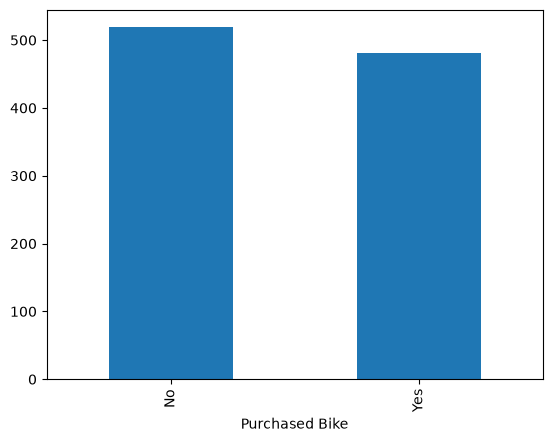

In [3]:
print(df.describe(include='all'))
print(df.isnull().sum())
print(df['Purchased Bike'].value_counts())
df['Purchased Bike'].value_counts().plot(kind='bar')
plt.show()

##### 4. Preprocessing: fill in missing values, scale numerical values and apply one hot encoding on categorical data

In [4]:
if 'ID' in df.columns:
    df = df.drop(columns=['ID'])

X = df.drop(columns=['Purchased Bike'])
y = df['Purchased Bike'].map({'Yes': 1, 'No': 0})

cat = X.select_dtypes(include='object').columns
num = X.select_dtypes(exclude='object').columns

pre_knn = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), num),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('oh', OneHotEncoder(handle_unknown='ignore'))]), cat)
])
pre_xgb = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median'))]), num),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('oh', OneHotEncoder(handle_unknown='ignore'))]), cat)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


C:\Users\PC1\AppData\Local\Temp\ipykernel_29952\2421251473.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat = X.select_dtypes(include='object').columns


##### 5. Apply KNN to dataset and display confusion matrix results


              precision    recall  f1-score   support

           0       0.68      0.72      0.70       104
           1       0.67      0.62      0.65        96

    accuracy                           0.68       200
   macro avg       0.67      0.67      0.67       200
weighted avg       0.67      0.68      0.67       200



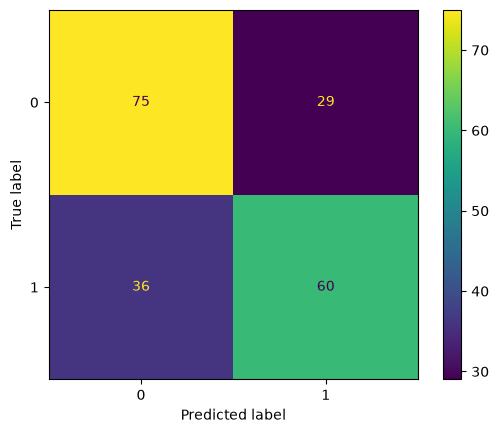

In [5]:
knn=Pipeline([('prep',pre_knn),('model',KNeighborsClassifier(n_neighbors=5))])
knn.fit(X_train,y_train)
pred=knn.predict(X_test)
print(classification_report(y_test,pred))
ConfusionMatrixDisplay.from_predictions(y_test,pred)
plt.show()
knn_metrics=[accuracy_score(y_test,pred),precision_score(y_test,pred),recall_score(y_test,pred),f1_score(y_test,pred)]


##### 6. Apply XGBoost to dataset and display confusion matrix results

              precision    recall  f1-score   support

           0       0.66      0.74      0.70       104
           1       0.68      0.59      0.63        96

    accuracy                           0.67       200
   macro avg       0.67      0.67      0.67       200
weighted avg       0.67      0.67      0.67       200



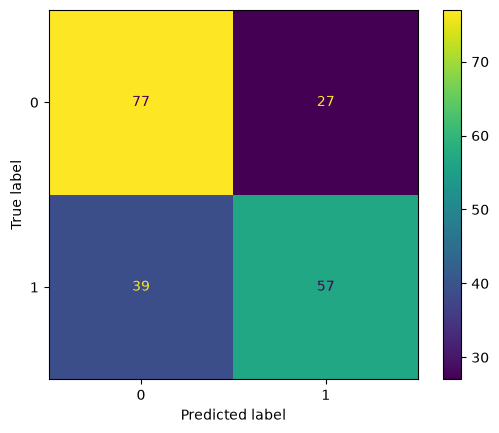

In [6]:
xgb=Pipeline([('prep',pre_xgb),('model',XGBClassifier(random_state=42,eval_metric='logloss'))])
xgb.fit(X_train,y_train)
pred2=xgb.predict(X_test)
print(classification_report(y_test,pred2))
ConfusionMatrixDisplay.from_predictions(y_test,pred2)
plt.show()
xgb_metrics=[accuracy_score(y_test,pred2),precision_score(y_test,pred2),recall_score(y_test,pred2),f1_score(y_test,pred2)]


##### 7. Comparison: caompare accuracy, precision, recall and f1 results

In [7]:
results=pd.DataFrame({
'Model':['KNN','XGBoost'],
'Accuracy':[knn_metrics[0],xgb_metrics[0]],
'Precision':[knn_metrics[1],xgb_metrics[1]],
'Recall':[knn_metrics[2],xgb_metrics[2]],
'F1':[knn_metrics[3],xgb_metrics[3]]
})
display(results)

,Model,Accuracy,Precision,Recall,F1
0,KNN,0.675,0.674157,0.62500,0.648649
1,XGBoost,0.670,0.678571,0.59375,0.633333


### Conclusion
On this dataset, KNN and XGBoost had similar accuracy and precision results. KNN had a higher Recall and F1 results, meaning KNN catches more true positives. Though for a dataset that has 1000 samples, the difference in recall is insignificant. This dataset was close to 50-50 in split, both models did learn some respresentations, but they didn't perform that much better than pure guessing (%50 accuracy). Dataset can be found on [Kaggle](https://www.kaggle.com/datasets/heeraldedhia/bike-buyers)